# Plan 3 deployment results

Fresh paired confirmation only. The underlying experiment keeps the original 100-point linear path; plots intentionally show only $0 \le p < .5$.

In [1]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd().resolve()
if ROOT.name == 'mnist_experiment':
    ROOT = ROOT.parent
analysis_root = ROOT / 'cache/mnist_experiment/plan3/analysis'
candidates = sorted(analysis_root.glob('phase7__*/summary.json'), key=lambda p: p.stat().st_mtime)
if not candidates:
    raise FileNotFoundError('No completed Phase 7 analysis. Run analyze-phase7 first.')
summary_path = candidates[-1]
if not (summary_path.parent / 'COMPLETED').is_file():
    raise RuntimeError(f'Incomplete analysis artifact: {summary_path.parent}')
summary = json.loads(summary_path.read_text())
if summary.get('schema_version') != 1:
    raise RuntimeError('Unsupported Phase 7 analysis schema')
print(summary_path.parent.name)
print(summary['precision_gate'])

phase7__plan3-fresh-confirmation__r0011-r0025__89c1451b1983__n10__85db75d1349e
{'completed_replica_count': 10, 'maximum_reached': False, 'maximum_replica_count': 15, 'median_pointwise_ci_half_width': 0.026560237915128664, 'median_pointwise_ci_half_width_target': 0.03, 'minimum_replica_count': 10, 'nine_ovr_practically_equivalent': True, 'precision_target_met': True, 'primary_auc_ci_half_width': 0.018729949126947913, 'primary_auc_ci_half_width_target': 0.02, 'primary_effect_positive': True, 'recommendation': 'stop_precision_target_met'}


In [2]:
LABELS = {
    'confirm-current-only': 'Current only',
    'confirm-ewc-fixed005': 'EWC, pi=.05',
    'confirm-hybrid-b032-fixed005': 'Hybrid B32, pi=.05',
    'confirm-replay-b032': 'Replay B32',
    'confirm-replay-unbounded': 'Unbounded replay',
}
METRICS = {
    'environment_accuracy': 'Environmental multiclass accuracy',
    'nine_ovr_accuracy': 'Digit-9 one-vs-rest accuracy',
    'nine_precision': 'Digit-9 precision',
    'nine_recall': 'Digit-9 recall',
}
trajectory = summary['expected_trajectories']
differences = summary['pointwise_paired_differences']

def plot_contrast(treatment, comparison, metric):
    fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True, height_ratios=(2, 1))
    for condition in (comparison, treatment):
        rows = [r for r in trajectory if r['condition'] == condition]
        p = np.asarray([r['p'] for r in rows], dtype=float)
        center = np.asarray([r[metric]['mean'] for r in rows], dtype=float)
        low = np.asarray([np.nan if r[metric]['ci95_low'] is None else r[metric]['ci95_low'] for r in rows], dtype=float)
        high = np.asarray([np.nan if r[metric]['ci95_high'] is None else r[metric]['ci95_high'] for r in rows], dtype=float)
        line, = axes[0].plot(p, center, label=LABELS[condition], linewidth=2)
        axes[0].fill_between(p, low, high, color=line.get_color(), alpha=.18)
    rows = [r for r in differences if r['treatment'] == treatment and r['comparison'] == comparison]
    p = np.asarray([r['p'] for r in rows], dtype=float)
    center = np.asarray([r[metric]['mean'] for r in rows], dtype=float)
    low = np.asarray([np.nan if r[metric]['ci95_low'] is None else r[metric]['ci95_low'] for r in rows], dtype=float)
    high = np.asarray([np.nan if r[metric]['ci95_high'] is None else r[metric]['ci95_high'] for r in rows], dtype=float)
    axes[1].axhline(0, color='black', linewidth=1)
    axes[1].plot(p, center, color='tab:green', linewidth=2)
    axes[1].fill_between(p, low, high, color='tab:green', alpha=.18)
    axes[0].set_ylabel(METRICS[metric])
    axes[0].set_ylim(0, 1)
    axes[0].legend(frameon=False)
    axes[1].set_ylabel('Paired difference')
    axes[1].set_xlabel('Environment coordinate p')
    axes[0].grid(alpha=.2)
    axes[1].grid(alpha=.2)
    fig.tight_layout()
    return fig

## Low-data learning controls

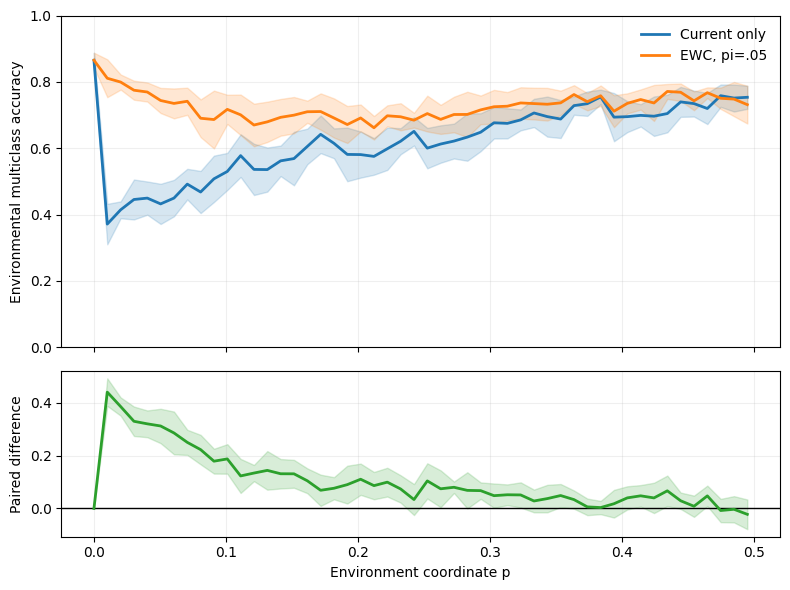

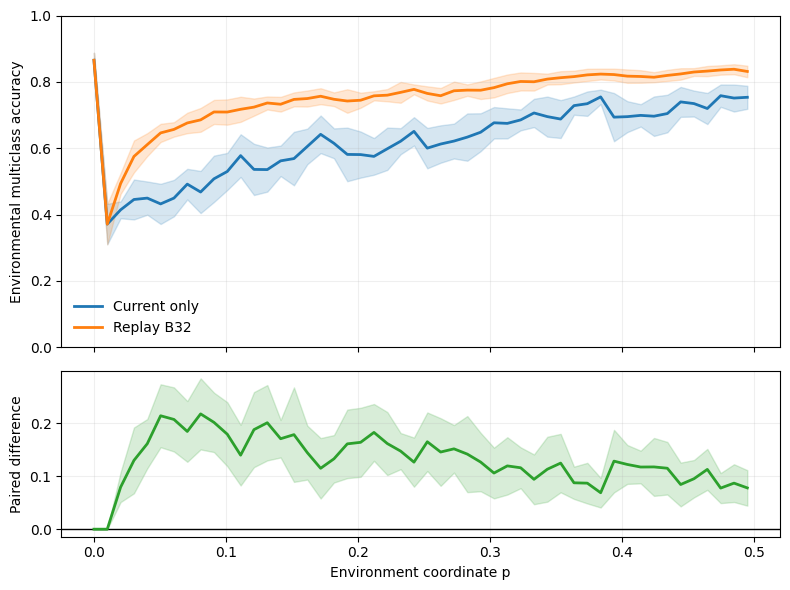

In [3]:
plot_contrast('confirm-ewc-fixed005', 'confirm-current-only', 'environment_accuracy');
plot_contrast('confirm-replay-b032', 'confirm-current-only', 'environment_accuracy');

## Compressed hybrid versus replay

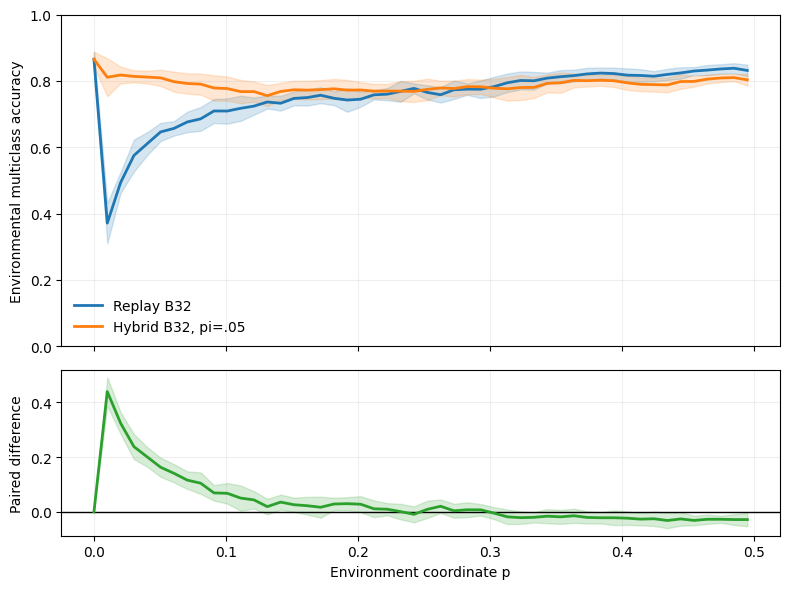

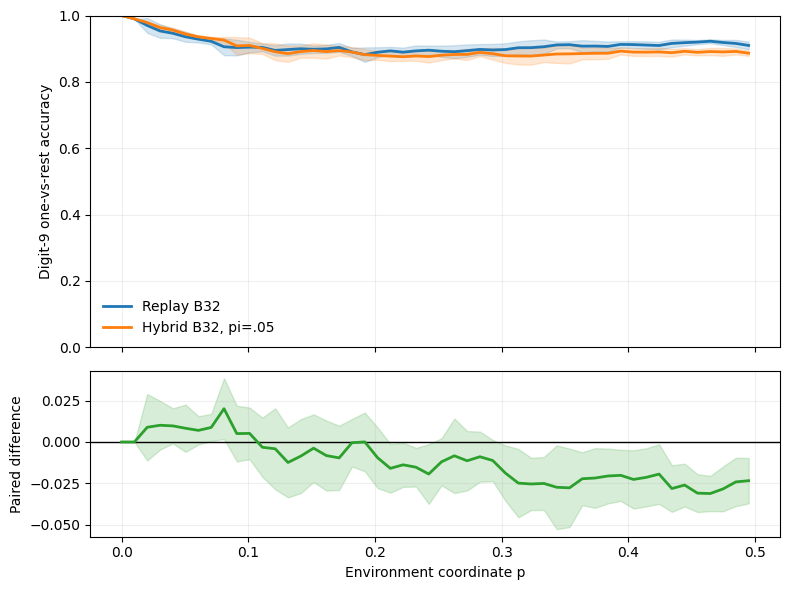

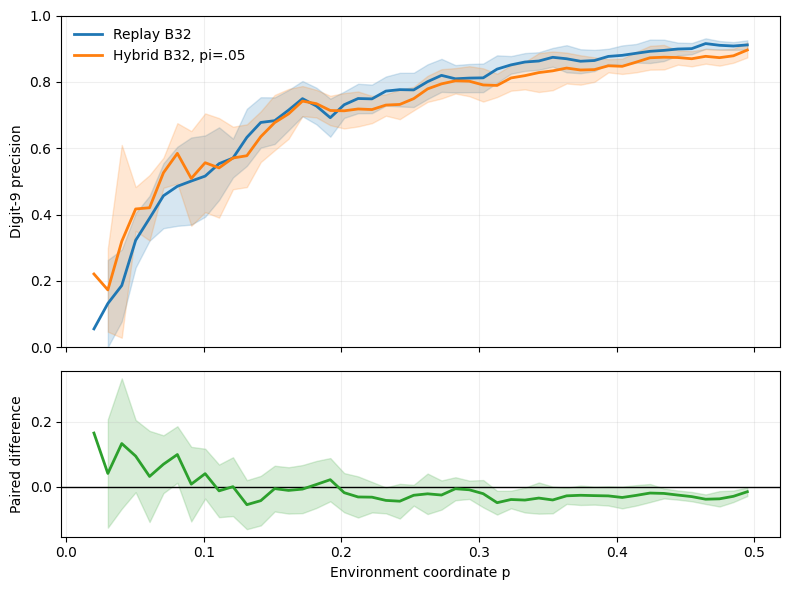

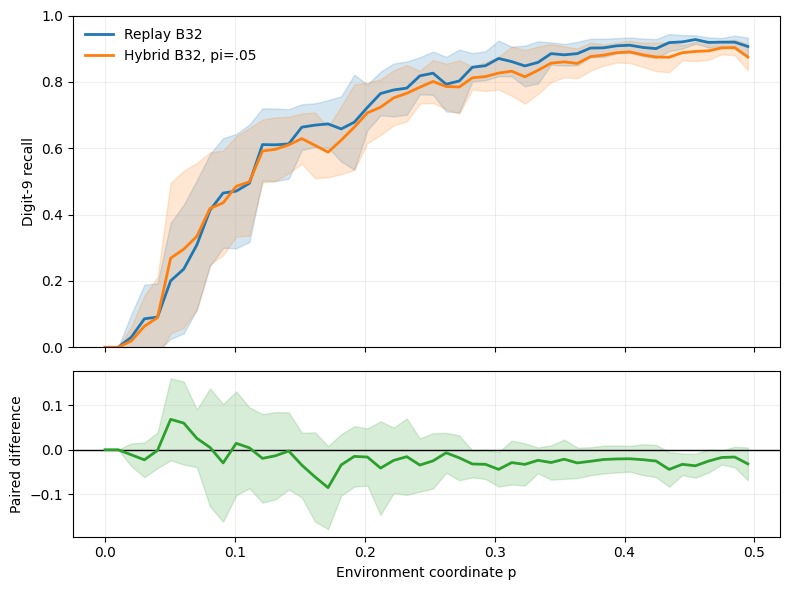

In [4]:
for metric in METRICS:
    plot_contrast('confirm-hybrid-b032-fixed005', 'confirm-replay-b032', metric)

## Hardware-constrained hybrid versus unbounded replay

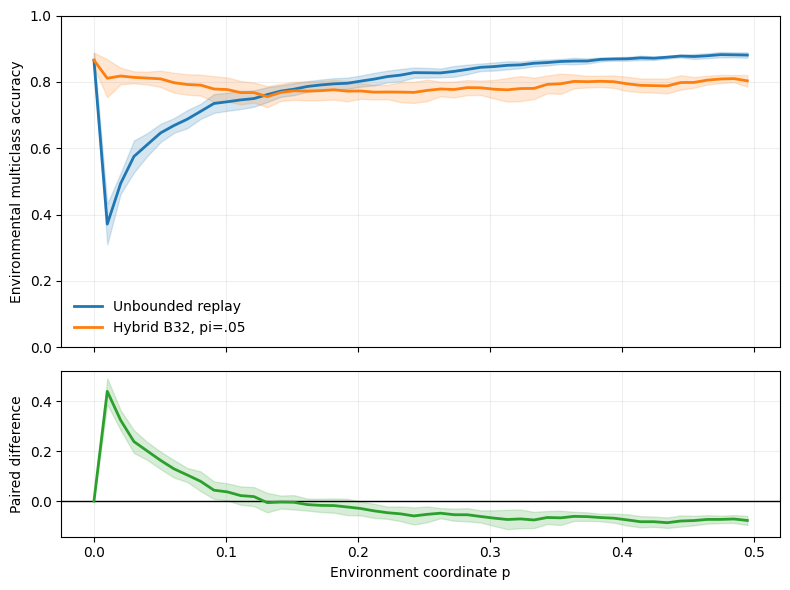

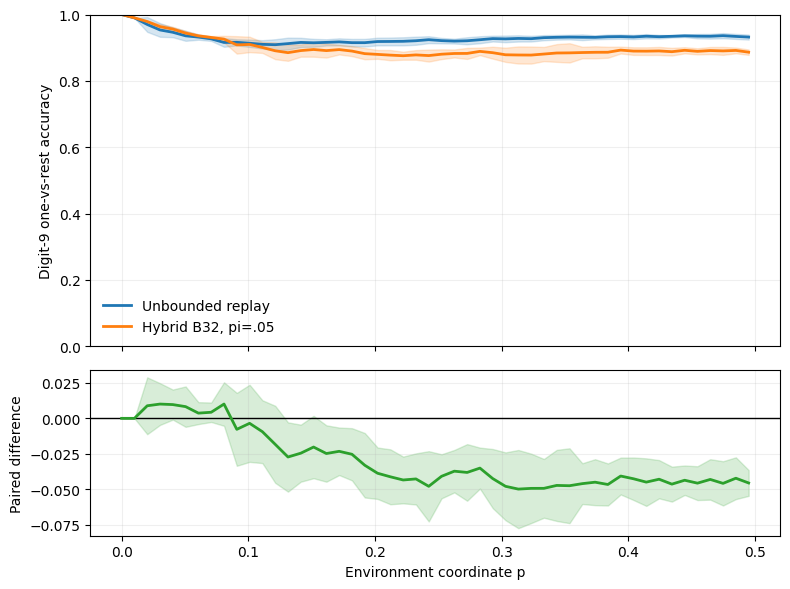

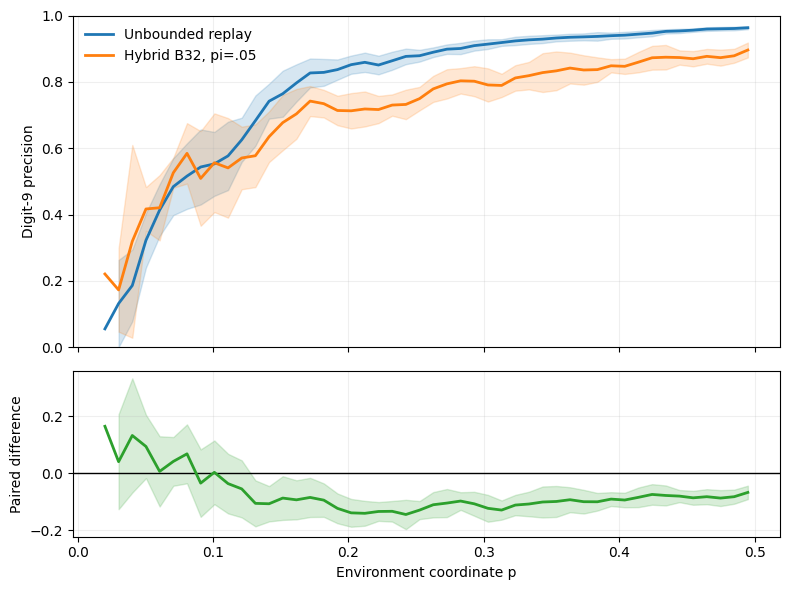

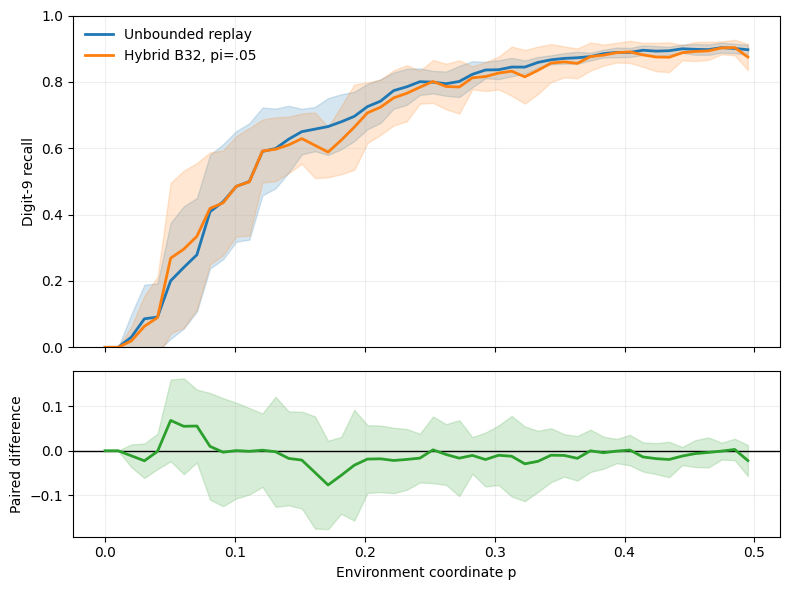

In [5]:
for metric in METRICS:
    plot_contrast('confirm-hybrid-b032-fixed005', 'confirm-replay-unbounded', metric)

## Initial Fisher assumption check

The adaptive estimator is valid at its maximum budget even when its stringent six-sigma early-stop criterion is not met.

{'converged_count': 0,
 'draw_duplicate_fraction': {'ci95_high': 0.7168358918308443,
  'ci95_low': 0.7159033659816557,
  'count': 10,
  'mean': 0.71636962890625,
  'standard_deviation': 0.000651835910791048,
  'standard_error': 0.00020612861387900395},
 'lag_one_frobenius_correlation': {'ci95_high': 0.003328372505711566,
  'ci95_low': -0.04430475435167135,
  'count': 10,
  'mean': -0.02048819092297989,
  'standard_deviation': 0.03329557315319815,
  'standard_error': 0.010528984716486054},
 'maximum_budget_count': 10,
 'relative_confidence_radius': {'ci95_high': 0.25370692341572126,
  'ci95_low': 0.2069374711652971,
  'count': 10,
  'mean': 0.23032219729050918,
  'standard_deviation': 0.03269186428599207,
  'standard_error': 0.01033807521008492},
 'replica_count': 10,
 'represented_diagonal_relative_error': {'ci95_high': 0.0024389288748081573,
  'ci95_low': 0.00021957430546269718,
  'count': 10,
  'mean': 0.0013292515901354273,
  'standard_deviation': 0.0015513296584071096,
  'standard_

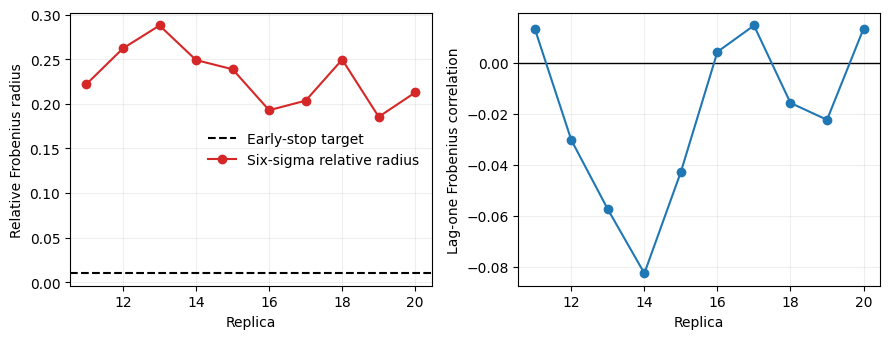

In [6]:
archive = summary['initial_archive_diagnostics']
archive_summary = summary['initial_archive_summary']
x = np.asarray([r['replica_index'] for r in archive], dtype=int)
radius = np.asarray([r['relative_confidence_radius'] for r in archive], dtype=float)
lag_one = np.asarray([r['lag_one_frobenius_correlation'] for r in archive], dtype=float)
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
axes[0].axhline(archive[0]['relative_epsilon'], color='black', linestyle='--', label='Early-stop target')
axes[0].plot(x, radius, marker='o', color='tab:red', label='Six-sigma relative radius')
axes[0].set_ylabel('Relative Frobenius radius')
axes[0].set_xlabel('Replica')
axes[0].legend(frameon=False)
axes[1].axhline(0, color='black', linewidth=1)
axes[1].plot(x, lag_one, marker='o', color='tab:blue')
axes[1].set_ylabel('Lag-one Frobenius correlation')
axes[1].set_xlabel('Replica')
for axis in axes:
    axis.grid(alpha=.2)
fig.tight_layout()
archive_summary

In [7]:
rows = []
for condition in summary['condition_auc']:
    rows.append({
        'condition': LABELS[condition['condition']],
        **{name: condition[name]['mean'] for name in METRICS},
    })
rows

[{'condition': 'Current only',
  'environment_accuracy': 0.6177932067635494,
  'nine_ovr_accuracy': 0.8518656596190711,
  'nine_precision': 0.6424769333107327,
  'nine_recall': 0.6192947149127243},
 {'condition': 'EWC, pi=.05',
  'environment_accuracy': 0.7257962749538567,
  'nine_ovr_accuracy': 0.86201451637492,
  'nine_precision': 0.6586131060819143,
  'nine_recall': 0.624490807224773},
 {'condition': 'Hybrid B32, pi=.05',
  'environment_accuracy': 0.7874545108403347,
  'nine_ovr_accuracy': 0.8991390130892108,
  'nine_precision': 0.7448931410331749,
  'nine_recall': 0.6635818450274064},
 {'condition': 'Replay B32',
  'environment_accuracy': 0.7509881146392404,
  'nine_ovr_accuracy': 0.9107672013142706,
  'nine_precision': 0.7610246066429533,
  'nine_recall': 0.6825660888736069},
 {'condition': 'Unbounded replay',
  'environment_accuracy': 0.7917658142856228,
  'nine_ovr_accuracy': 0.9289474116964971,
  'nine_precision': 0.8308236987518308,
  'nine_recall': 0.6727796767864728}]